In [49]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


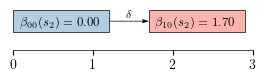

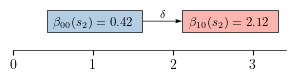

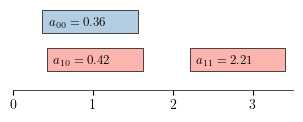

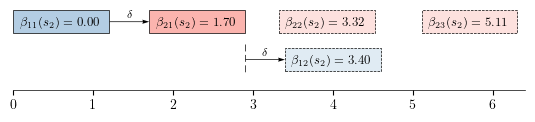

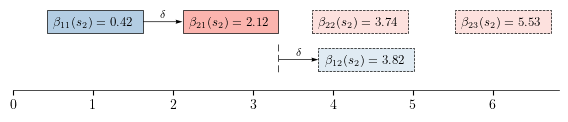

In [ ]:
from single.basics import SingleInstance, generate_simple_instance, generate_instance, uniform
from single.mdp import SingleScheduleEnv
import numpy as np

i1 = generate_instance(uniform(0.1, 0.5), n=[1,1])
i1.arrivals[0][0] = 0
i2 = generate_instance(uniform(0.1, 0.5), n=[1,1])
# i1 = generate_simple_instance(n=[1,1])
# i2 = generate_simple_instance(n=[1,1])
env1 = SingleScheduleEnv(instance=i1)
env2 = SingleScheduleEnv(instance=i2)

env1.reset()
env2.reset()
env1.step(0); env1.step(1)
env2.step(0); env2.step(1)

env1.render()
env2.render()

# - take the current schedule lower bounds
# - append the same postfix
# - execute the current partial schedule
def ext(env, postfix, plotname):
    makespan = env.makespan()
    extended = SingleInstance()
    for r in [0, 1]:
        # current LBs in this route become arrivals
        current_LBr = env.LB[r, :env.n[r]]
        # time-shift the arrivals in the postfix
        new_arrivals = makespan + postfix.arrivals[r]
        # add the extended route
        ar = np.concatenate((current_LBr, new_arrivals))
        extended.add_route(ar)

    # execute the previous partial order to arrive again at almost the
    # same partial state, but now with unscheduled vehicles at the end
    env_ext = SingleScheduleEnv(extended, options={'out':plotname, 'tex': True, 'one_based_indices': True})
    env_ext.reset()
    for r in env.route_order:
        env_ext.step(r)
    return env_ext

postfix = generate_simple_instance(n=[1,2])
postfix.visualize()

env1_ext = ext(env1, postfix, 'figures/abstract1.pdf')
env2_ext = ext(env2, postfix, 'figures/abstract2.pdf')

env1_ext.render()
env2_ext.render()

In [51]:
import fitz  # PyMuPDF

pdfs = ['figures/abstract1.pdf', 'figures/abstract2.pdf']
docs = [fitz.open(path) for path in pdfs]
pages = [doc.load_page(0) for doc in docs]

# gap between source pages
gap = 25

# compute total output size
width = max(page.rect.width for page in pages)
height = sum(page.rect.height for page in pages) + gap * (len(pages) - 1)

# create an output document and one large page
out = fitz.open()
out_page = out.new_page(width=width, height=height)

# paste each PDF page below the previous one
y = 0
for doc, page in zip(docs, pages):
    rect = page.rect

    # draw border rectangle
    # page.draw_rect(
    #     rect,
    #     color=(0.5, 0.5, 0.5),
    #     width=1,           # border line width in points
    # )

    out_page.show_pdf_page(
        fitz.Rect(0, y, rect.width, y + rect.height),  # target rectangle
        doc,                                           # source document
        0                                              # source page number
    )
    y += rect.height + gap

# save and close everything
out.save("figures/abstract.pdf")
for d in docs:
    d.close()
out.close()


In [52]:
env = env1_ext

earliest_r_LB_pairs = [(r, env.LB[r, env.k[r]]) for r in range(env.R) if not env.done[r]]
earliest_r_LB_pairs

[(0, 3.4), (1, 3.3212353614349452)]

In [53]:
def current_time(env):
    if len(earliest_r_LB_pairs) == 1:
        # take the lb of the only remaining unscheduled vehicle
        return earliest_r_LB_pairs[0][1]
    else:
        # sort the (r, LB) pairs in ascending order
        earliest_r_LB_pairs.sort(key=lambda e: e[1])
        # take the smallest of (smallest LB, second smallest LB - switch)
        return min(
            earliest_r_LB_pairs[0][1],
            earliest_r_LB_pairs[1][1] - env.switch
        )

In [54]:
print(current_time(env1_ext), current_time(env2_ext))

2.9 2.9
